In [1]:
!pip install weaviate-client -qqq

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import torch
from sentence_transformers import SentenceTransformer
import weaviate
import weaviate.classes.config as wc
import weaviate.classes.query as wq
from sentence_transformers import SentenceTransformer
from typing import List, Dict, Union
from tqdm.auto import tqdm

2026-01-04 05:30:38.154716: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767504638.177425     161 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767504638.184279     161 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767504638.202167     161 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767504638.202187     161 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767504638.202189     161 computation_placer.cc:177] computation placer alr

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
embedder = SentenceTransformer("ibm-granite/granite-embedding-small-english-r2").to(device)

In [4]:
df = pd.read_csv('/kaggle/input/57651-spotify-songs/Spotify Million Song Dataset_exported.csv')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
df.sample(5)

,artist,song,link,text
43394,Meat Loaf,Lost Boys And Golden Girls,/m/meat+loaf/lost+boys+golden+girls_20091251.html,Lost boys and golden girls \nDown on the corn...
18658,Squeeze,Images Of Loving,/s/squeeze/images+of+loving_20129288.html,Your initials on the singles \nThat you chose...
51828,Snoop Dogg,Gin And Juice,/s/snoop+dogg/gin+juice_20127119.html,Heah hah hah! \nI'm serious nigga one of y'al...
174,Aerosmith,No Surprize,/a/aerosmith/no+surprize_20004406.html,Nineteen seventy one \nWe all heard the start...
30195,Donna Summer,Rumour Has It,/d/donna+summer/rumour+has+it_10087849.html,"There's a rumour, there's a rumour \nRumour h..."


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [6]:
artists = Counter(df.artist)
artists = dict(sorted(artists.items(), key=lambda x: x[1], reverse=True))

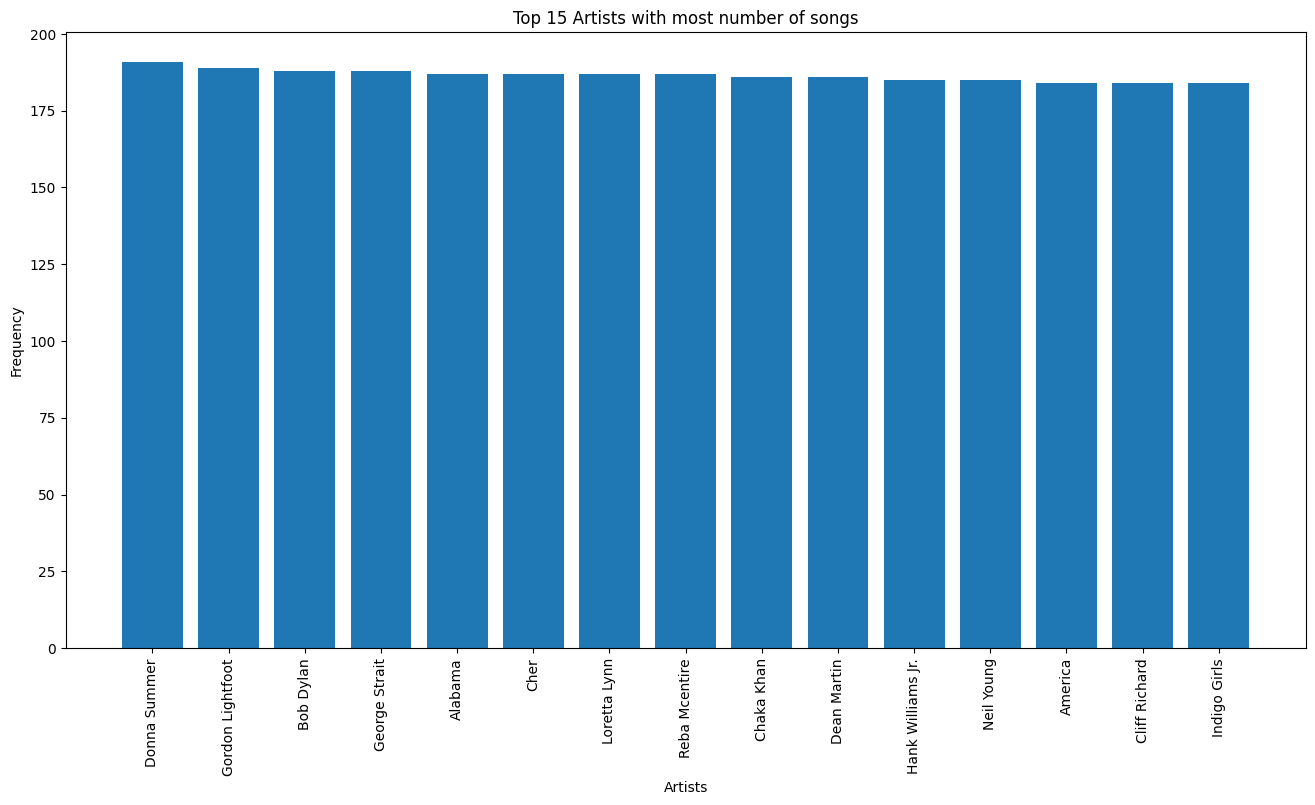

In [7]:
plt.figure(figsize=(16,8))
plt.bar(list(artists.keys())[:15],list(artists.values())[:15])
plt.title('Top 15 Artists with most number of songs')
plt.xlabel('Artists')
plt.ylabel('Frequency')
plt.xticks(rotation=90);

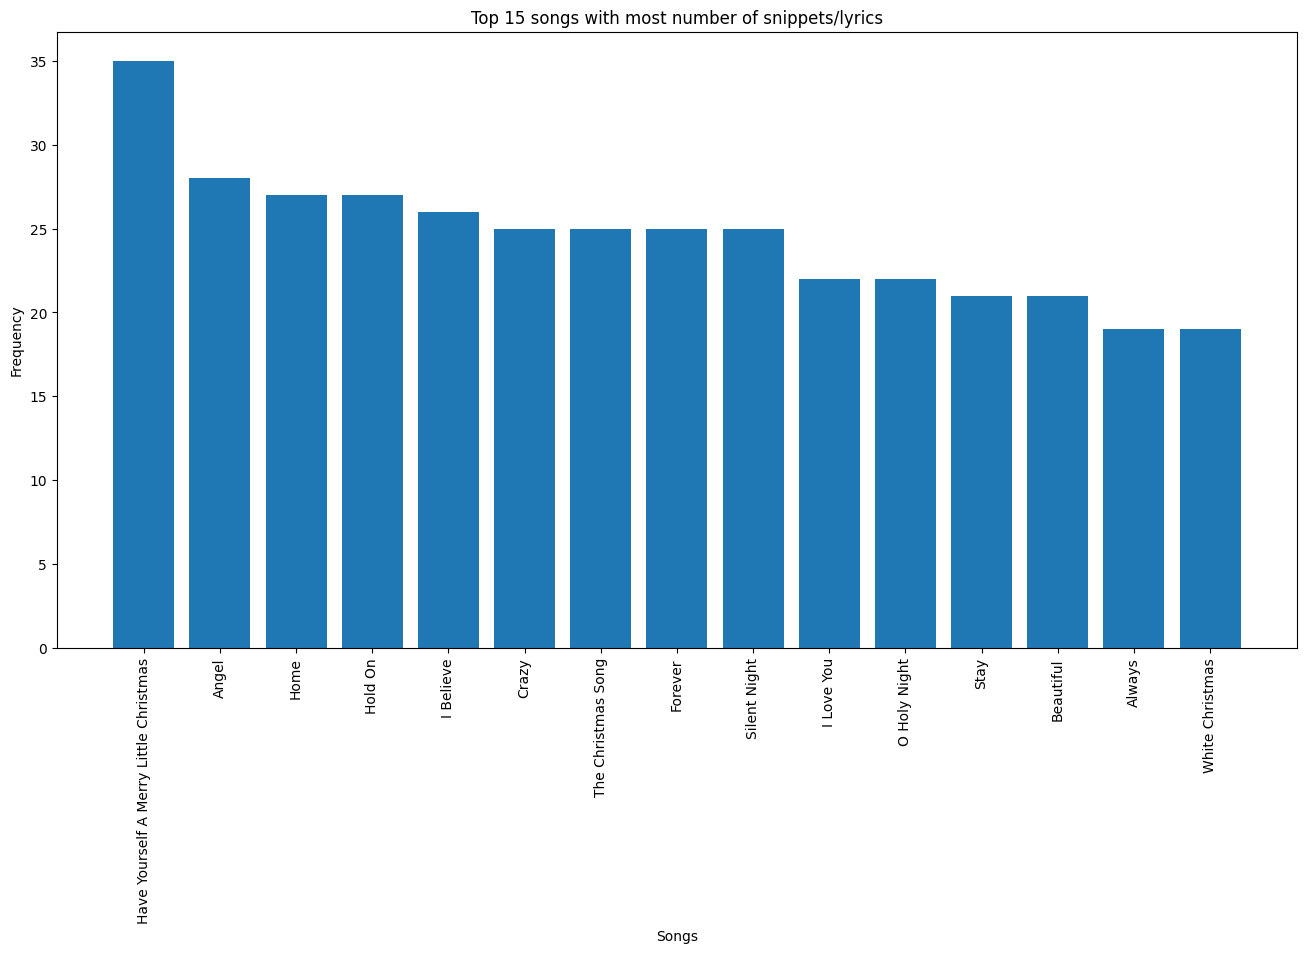

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [8]:
songs = df.song.value_counts()

plt.figure(figsize=(16,8))
plt.bar(songs.index[:15],songs.values[:15])
plt.title('Top 15 songs with most number of snippets/lyrics')
plt.xlabel('Songs')
plt.ylabel('Frequency')
plt.xticks(rotation=90);

  0%|          | 0/57650 [00:00<?, ?it/s]

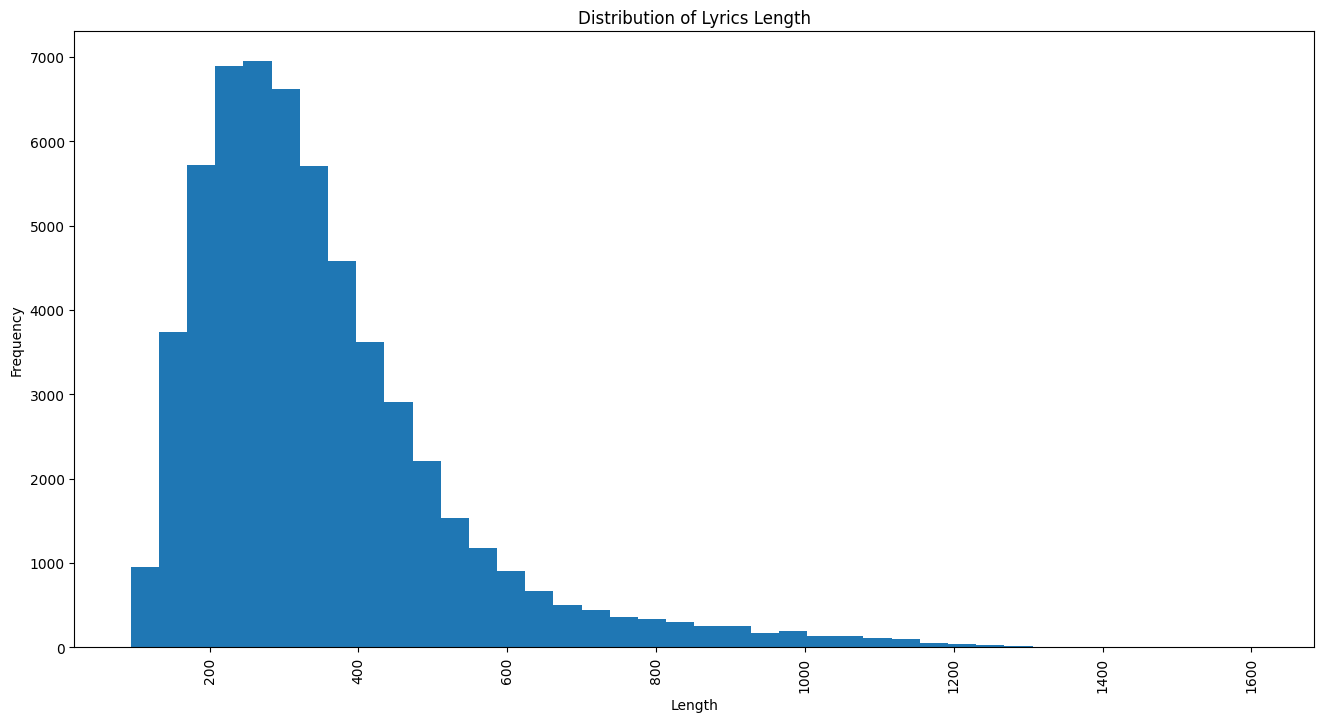

In [9]:
lengths = [len(embedder.tokenizer.tokenize(snip)) for snip in tqdm(df.text)]

plt.figure(figsize=(16,8))
plt.hist(lengths,bins=40)
plt.title('Distribution of Lyrics Length')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.xticks(rotation=90);

In [10]:
class VectorStore:
    def __init__(self, db_name: str, persistent_path: str, binary_path: str, embedding_model):
        self.db_name = db_name
        self.embedding_model = embedding_model
        self.persistent_path = persistent_path
        self.binary_path = binary_path
        self.client = None
        self._initialize_vector_store()

    def _initialize_vector_store(self):
        try:
            self.client = weaviate.connect_to_embedded(
                version="latest",
                binary_path=self.binary_path,
                persistence_data_path=self.persistent_path,
                environment_variables={"LOG_LEVEL": "error"} 
            )
            print(f"Vector Store initialized successfully!")
        except Exception as e:
            print(f"Vector Store initialization failed: {e}")

    def create_store(self):
        if not self.client:
            return

        if self.client.collections.exists(self.db_name):
            self.client.collections.delete(self.db_name)
            print(f"Dropped existing collection: '{self.db_name}'")

        self.client.collections.create(
            name=self.db_name,
            description="SpotifySongs",
            vectorizer_config=[
                wc.Configure.NamedVectors.none(name="default")
            ],
            
            properties=[
                wc.Property(name="song", data_type=wc.DataType.TEXT),
                wc.Property(name="artist", data_type=wc.DataType.TEXT),
                wc.Property(name="text", data_type=wc.DataType.TEXT),
            ]
        )
        print(f"Vector Store Collection '{self.db_name}' created successfully.")

    def add_documents(self, data_list: list):
        if not self.client:
            return

        collection = self.client.collections.get(self.db_name)

        try:
            with collection.batch.dynamic() as batch:
                for c in tqdm(data_list, desc="Vectorizing & Uploading"):
                    vector = self.embedding_model.encode(c["text"], show_progress_bar=False).tolist()
                    
                    batch.add_object(
                        properties={
                            "song": c["song"],
                            "artist": c["artist"],
                            "text": c["text"]
                        },
                        vector={"default": vector}
                    )

            if len(collection.batch.failed_objects) > 0:
                print(f"Failed to import {len(collection.batch.failed_objects)} objects")
                print(collection.batch.failed_objects[0].message)
            else:
                print(f"Successfully added {len(data_list)} documents to {self.db_name}")
                
        except Exception as e:
            print(f"Error adding documents: {e}")

In [11]:
metadata = [
    {
        'artist': row['artist'].lower(),
        'song': row['song'].lower(),
        'text': row['text'].lower()
    }
    for _, row in tqdm(df.iterrows())
]

0it [00:00, ?it/s]

In [12]:
metadata[:2]

[{'artist': 'abba',
  'song': "ahe's my kind of girl",
  'text': "look at her face, it's a wonderful face  \nand it means something special to me  \nlook at the way that she smiles when she sees me  \nhow lucky can one fellow be?  \n  \nshe's just my kind of girl, she makes me feel fine  \nwho could ever believe that she could be mine?  \nshe's just my kind of girl, without her i'm blue  \nand if she ever leaves me what could i do, what could i do?  \n  \nand when we go for a walk in the park  \nand she holds me and squeezes my hand  \nwe'll go on walking for hours and talking  \nabout all the things that we plan  \n  \nshe's just my kind of girl, she makes me feel fine  \nwho could ever believe that she could be mine?  \nshe's just my kind of girl, without her i'm blue  \nand if she ever leaves me what could i do, what could i do?\n\n"},
 {'artist': 'abba',
  'song': 'andante, andante',
  'text': "take it easy with me, please  \ntouch me gently like a summer evening breeze  \ntake you

In [13]:
db_name = 'spotify_songs'
persistent_path = '/kaggle/working/vectordb'
binary_path = '/kaggle/working/vectordb'
vs = VectorStore(db_name,persistent_path,binary_path,embedder)
vs.create_store()

INFO:weaviate-client:Binary /kaggle/working/vectordb did not exist. Downloading binary from https://github.com/weaviate/weaviate/releases/download/v1.35.2/weaviate-v1.35.2-Linux-amd64.tar.gz
/usr/local/lib/python3.12/dist-packages/weaviate/embedded.py:148: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  binary_tar.extract("weaviate", path=Path(self.options.binary_path))
INFO:weaviate-client:Started /kaggle/working/vectordb: process ID 237
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Vector Store initialized successfully!
Vector Store Collection 'spotify_songs' created successfully.


/usr/local/lib/python3.12/dist-packages/weaviate/warnings.py:196: DeprecationWarning: Dep024: You are using the `vectorizer_config` argument in `collection.config.create()`, which is deprecated.
            Use the `vector_config` argument instead.
            
  warnings.warn(
{"build_git_commit":"","build_go_version":"go1.25.5","build_image_tag":"","build_wv_version":"1.35.2","error":"invalid default quantization for hnsw index: ","level":"error","msg":"error while setting default quantization","time":"2026-01-04T05:31:50Z"}


In [14]:
vs.add_documents(metadata)

Vectorizing & Uploading:   0%|          | 0/57650 [00:00<?, ?it/s]

W0104 05:31:56.500000 161 torch/_inductor/utils.py:1436] [1/0_1] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Successfully added 57650 documents to spotify_songs


In [17]:
print(vs.client.collections.list_all().keys())

dict_keys(['Spotify_songs'])


In [15]:
!zip -r vectordb.zip /kaggle/working/vectordb

  adding: kaggle/working/vectordb/ (stored 0%)
  adding: kaggle/working/vectordb/migration1.19.filter2search.skip.flag (stored 0%)
  adding: kaggle/working/vectordb/modules.db (deflated 99%)
  adding: kaggle/working/vectordb/raft/ (stored 0%)
  adding: kaggle/working/vectordb/raft/db_users/ (stored 0%)
  adding: kaggle/working/vectordb/raft/db_users/users.json (stored 0%)
  adding: kaggle/working/vectordb/raft/snapshots/ (stored 0%)
  adding: kaggle/working/vectordb/raft/raft.db (deflated 90%)
  adding: kaggle/working/vectordb/migration1.22.fs.hierarchy (stored 0%)
  adding: kaggle/working/vectordb/schema.db (deflated 99%)
  adding: kaggle/working/vectordb/classifications.db (deflated 99%)
  adding: kaggle/working/vectordb/migration1.19.filter2search.state (stored 0%)
  adding: kaggle/working/vectordb/spotify_songs/ (stored 0%)
  adding: kaggle/working/vectordb/spotify_songs/d4U6wzmPORh2/ (stored 0%)
  adding: kaggle/working/vectordb/spotify_songs/d4U6wzmPORh2/proplengths (deflated 47%

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/usr/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=161) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


 (deflated 79%)
  adding: kaggle/working/vectordb/spotify_songs/d4U6wzmPORh2/lsm/ (stored 0%)
  adding: kaggle/working/vectordb/spotify_songs/d4U6wzmPORh2/lsm/property_song/ (stored 0%)
  adding: kaggle/working/vectordb/spotify_songs/d4U6wzmPORh2/lsm/property_song/segment-1767505766693954963.wal (deflated 75%)
  adding: kaggle/working/vectordb/spotify_songs/d4U6wzmPORh2/lsm/property_song/segment-1767505705392746866.l0.s3.db (deflated 88%)
  adding: kaggle/working/vectordb/spotify_songs/d4U6wzmPORh2/lsm/property_song/segment-1767505705392746866.l0.s3.bloom (stored 0%)
  adding: kaggle/working/vectordb/spotify_songs/d4U6wzmPORh2/lsm/property_song/segment-1767505644221258849.l4.s3.bloom (stored 0%)
  adding: kaggle/working/vectordb/spotify_songs/d4U6wzmPORh2/lsm/property_song/segment-1767505644221258849.l4.s3.db (deflated 82%)
  adding: kaggle/working/vectordb/spotify_songs/d4U6wzmPORh2/lsm/property_text_searchable/ (stored 0%)
  adding: kaggle/working/vectordb/spotify_songs/d4U6wzmPORh2/